# Paper depth analyses — repeated splits, baselines, transfer breakdown, timing, interpretation, EDA, workflow schematic
Everything feeds `Model/paper_figures/`; hyperparameters are reused from `interp_row_42` (no re-tuning).

In [1]:
import sys, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ldh_pipeline as lp

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'savefig.dpi': 300,
})
SEED = lp.SEED
FIG_DIR = lp.MODEL_DIR / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)
print('Figures ->', FIG_DIR)

Figures -> /home/trunght/workspace/researches/Green-X Project-BaoTien/Model/paper_figures


In [2]:
df = lp.load_data(lp.DATA_DIR / '20260804_Data_Adsorption.xlsx')
y_full = df['RR %']
groups_full = df['Id'].values
X_full = df.drop(columns=['Id', 'RR %'])
saved = joblib.load(lp.MODEL_DIR / 'interp_row_42' / 'saved_models.joblib')
MODELS = {k: saved[k] for k in ('LR', 'KNN', 'ANN', 'Cubist', 'RF', 'XGB', 'HistGB')}

# duplicate-free view for the interpolation task (matches interp_row_42)
keep = ~X_full.duplicated(keep='first')
Xd = X_full[keep].reset_index(drop=True)
yd = y_full[keep].reset_index(drop=True)
ids_d = df['Id'][keep].reset_index(drop=True)
tp_d = df['TP'][keep].reset_index(drop=True)
print(f"full: {len(df)} rows | dedup: {len(Xd)} rows | studies: {ids_d.nunique()}")

full: 1342 rows | dedup: 1259 rows | studies: 57


## A1. Repeated-split interpolation (20 seeded 80/20 splits) + naive baselines

In [3]:
rep = lp.repeated_interpolation(MODELS, Xd, yd, n_repeats=20)
rep.to_csv(FIG_DIR / 'repeated_interp_models.csv', index=False)
base = lp.baseline_repeated_interpolation(
    yd, keys={'per-pollutant mean': tp_d, 'per-study mean': ids_d}, n_repeats=20)
base.to_csv(FIG_DIR / 'repeated_interp_baselines.csv', index=False)

both = pd.concat([rep, base])
summ = both.groupby('model')[['r2', 'mae', 'rmse']].agg(['mean', 'std']).round(3)
summ.columns = ['_'.join(c) for c in summ.columns]
summ = summ.sort_values('mae_mean')
summ.to_csv(FIG_DIR / 'repeated_interp_summary.csv')
summ

,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
model,,,,,,
XGB,0.842,0.029,6.277,0.558,11.092,0.952
HistGB,0.850,0.028,6.344,0.530,10.785,0.957
KNN,0.733,0.061,7.821,0.805,14.372,1.467
Cubist,0.793,0.032,8.041,0.566,12.723,0.967
RF,0.784,0.033,8.608,0.480,12.974,0.921
ANN,0.536,0.045,14.411,0.699,19.062,0.904
per-study mean,0.427,0.053,16.665,0.801,21.178,0.947
LR,0.400,0.040,17.391,0.544,21.702,0.731
per-pollutant mean,0.179,0.030,21.422,0.606,25.388,0.640


## A2. LOSO baselines — do the models beat a per-pollutant average for a new study?

In [4]:
loso = pd.read_csv(FIG_DIR / 'loso_per_study.csv')
bl = lp.baseline_loso(y_full, groups_full, keys={'per-pollutant mean': df['TP']})
bl.to_csv(FIG_DIR / 'loso_baselines.csv', index=False)

print('LOSO median MAE:')
print(pd.concat([loso.groupby('model')['mae'].median(),
                 bl.groupby('model')['mae'].median()]).sort_values().round(2))

best = loso[loso.model == 'Cubist'][['study', 'mae']].rename(columns={'mae': 'model_mae'})
tp_bl = bl[bl.model == 'per-pollutant mean'][['study', 'mae']].rename(columns={'mae': 'baseline_mae'})
head2head = best.merge(tp_bl, on='study')
wins = (head2head.model_mae < head2head.baseline_mae).sum()
print(f"Cubist beats the per-pollutant-mean baseline in {wins} of {len(head2head)} studies")
pd.DataFrame([{'model': 'Cubist', 'wins': wins, 'n': len(head2head)}]).to_csv(
    FIG_DIR / 'loso_head2head.csv', index=False)

LOSO median MAE:
model
Cubist                14.11
KNN                   16.00
HistGB                16.40
RF                    16.81
ANN                   18.13
XGB                   18.33
global mean           24.23
per-pollutant mean    25.13
LR                    28.40
Name: mae, dtype: float64
Cubist beats the per-pollutant-mean baseline in 41 of 59 studies


## A3. Transfer breakdown — which chemistries transfer?

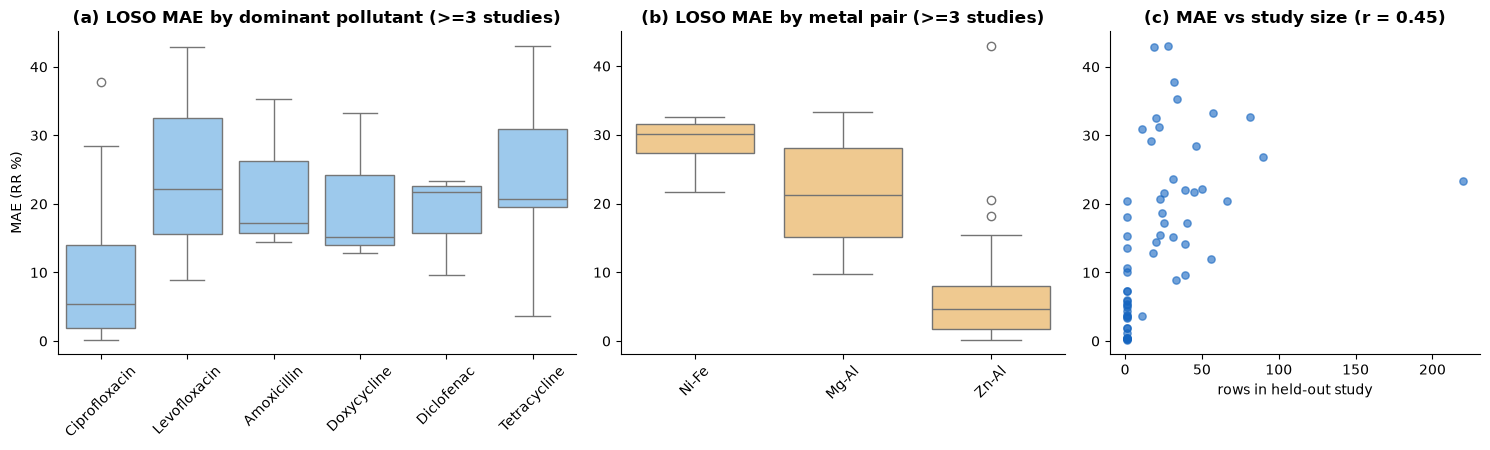

spread corr r(rr_spread, mae) = 0.45


In [5]:
attrs = (df.groupby('Id').agg(
    tp=('TP', lambda s: s.mode().iat[0]),
    metal2=('Metal(II)', lambda s: s.mode().iat[0]),
    metal3=('Metal(III)', lambda s: s.mode().iat[0]),
    n_rows=('TP', 'size'),
    rr_spread=('RR %', 'std'))
    .reset_index().rename(columns={'Id': 'study'}))
attrs['metal_pair'] = attrs['metal2'] + '-' + attrs['metal3']
tb = loso[loso.model == 'Cubist'].drop(columns=['n_rows']).merge(attrs, on='study')
tb.to_csv(FIG_DIR / 'transfer_breakdown.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.4, 1.2, 1]})
tp_counts = tb['tp'].value_counts()
tp_keep = tp_counts[tp_counts >= 3].index
sns.boxplot(data=tb[tb.tp.isin(tp_keep)], x='tp', y='mae', ax=axes[0], color='#90CAF9')
axes[0].set_title('(a) LOSO MAE by dominant pollutant (>=3 studies)')
axes[0].set_xlabel(''); axes[0].set_ylabel('MAE (RR %)')
axes[0].tick_params(axis='x', rotation=45)

mp_counts = tb['metal_pair'].value_counts()
mp_keep = mp_counts[mp_counts >= 3].index
sns.boxplot(data=tb[tb.metal_pair.isin(mp_keep)], x='metal_pair', y='mae', ax=axes[1],
            color='#FFCC80')
axes[1].set_title('(b) LOSO MAE by metal pair (>=3 studies)')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

axes[2].scatter(tb['n_rows'], tb['mae'], alpha=0.6, s=28, color='#1565C0')
r_n = np.corrcoef(tb['n_rows'], tb['mae'])[0, 1]
axes[2].set_title(f'(c) MAE vs study size (r = {r_n:.2f})')
axes[2].set_xlabel('rows in held-out study'); axes[2].set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_transfer_breakdown.png', bbox_inches='tight')
plt.show()
print('spread corr r(rr_spread, mae) =', round(np.corrcoef(tb.dropna(subset=['rr_spread'])['rr_spread'], tb.dropna(subset=['rr_spread'])['mae'])[0,1], 2))

## A4. Computation time

In [6]:
Xtr, Xte, ytr, yte, _ = lp.make_split(Xd, yd, groups=None, test_size=0.2, seed=SEED)
rows = []
for name, model in MODELS.items():
    from sklearn.base import clone
    m = clone(model)
    t0 = time.perf_counter(); m.fit(Xtr, ytr); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); m.predict(Xte); t_pred = time.perf_counter() - t0
    rows.append({'model': name, 'fit_s': round(t_fit, 2), 'predict_s': round(t_pred, 3)})
timing = pd.DataFrame(rows).sort_values('fit_s')
timing.to_csv(FIG_DIR / 'computation_time.csv', index=False)
timing

,model,fit_s,predict_s
1,KNN,0.05,0.041
0,LR,0.14,0.050
3,Cubist,0.22,0.043
4,RF,0.37,0.089
2,ANN,0.67,0.014
6,HistGB,0.86,0.078
5,XGB,10.07,0.031


## A5. Interpretation depth — multi-model permutation ranks, SHAP interaction, PDP

In [7]:
fitted = {}
for name, model in MODELS.items():
    from sklearn.base import clone
    m = clone(model); m.fit(Xtr, ytr); fitted[name] = {'model': m}
ranks = lp.permutation_ranks(fitted, Xte, yte)
ranks.to_csv(FIG_DIR / 'perm_ranks_all_models.csv')
ranks['median_rank'] = ranks.median(axis=1)
ranks.sort_values('median_rank').head(12)

,LR,KNN,ANN,Cubist,RF,XGB,HistGB,median_rank
AD g/L,27,1,29,1,1,1,1,1.0
Time h,19,3,1,2,2,2,2,2.0
Ci mg/L,22,4,14,3,3,4,3,4.0
pH,25,2,4,5,7,5,4,5.0
BET m2/g,24,5,2,7,6,6,6,6.0
pHpzc,26,7,19,9,4,7,5,7.0
d(003) nm,8,6,8,8,12,8,10,8.0
average Pauling electronegativity,15,13,7,15,9,9,8,9.0
Log Kow,11,9,16,18,5,3,7,9.0
PV cm3/g,10,16,12,4,8,10,9,10.0


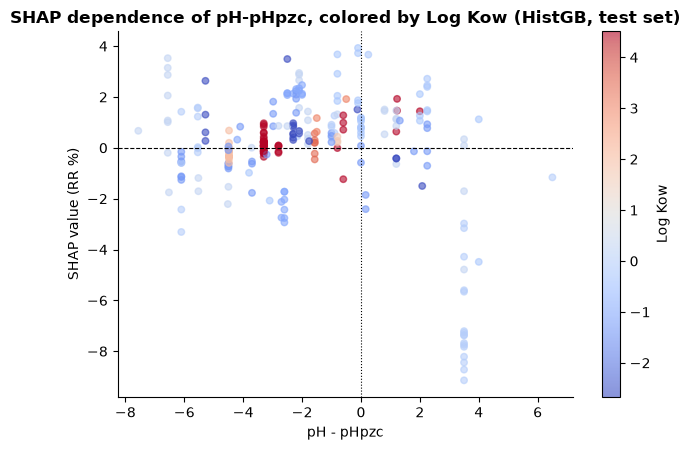

In [8]:
import shap
eng_models = joblib.load(lp.MODEL_DIR / 'interp_row_eng_42' / 'saved_models.joblib')
X_eng_full = lp.add_engineered_features(X_full)
keep_e = ~X_eng_full.duplicated(keep='first')
Xe = X_eng_full[keep_e].reset_index(drop=True)
ye = y_full[keep_e].reset_index(drop=True)
Xtr_e, Xte_e, ytr_e, yte_e, _ = lp.make_split(Xe, ye, groups=None, test_size=0.2, seed=SEED)
res_eng = {'model': eng_models['HistGB'], 'label': 'HistGB'}
sv, names = lp.shap_summary(res_eng, Xte_e)

j = names.index('pH-pHpzc'); k = names.index('Log Kow')
fig, ax = plt.subplots(figsize=(6.5, 4.6))
sc = ax.scatter(sv.data[:, j], sv.values[:, j], c=sv.data[:, k], cmap='coolwarm',
                alpha=0.6, s=22)
plt.colorbar(sc, label='Log Kow')
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('pH - pHpzc'); ax.set_ylabel('SHAP value (RR %)')
ax.set_title('SHAP dependence of pH-pHpzc, colored by Log Kow (HistGB, test set)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_shap_interaction.png', bbox_inches='tight')
plt.show()

PDP features: ['AD g/L', 'Time h', 'Ci mg/L']


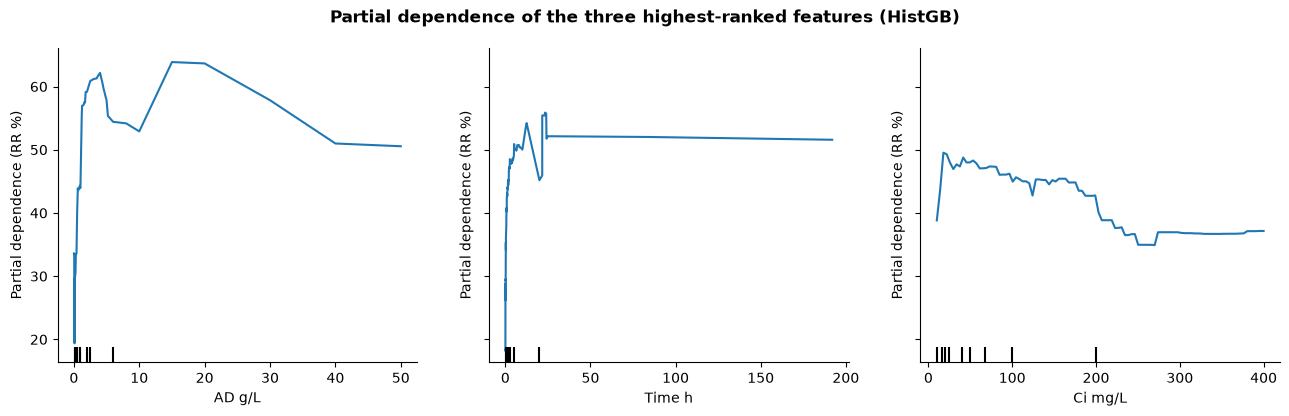

In [9]:
from sklearn.inspection import PartialDependenceDisplay
top3 = [f for f in ranks.sort_values('median_rank').index if f in Xd.columns][:3]
print('PDP features:', top3)
fig, ax = plt.subplots(figsize=(13, 4.2))
disp = PartialDependenceDisplay.from_estimator(
    fitted['HistGB']['model'], Xtr, top3, kind='average', ax=ax)
for a in disp.axes_.ravel():
    if a is not None:
        a.set_ylabel('Partial dependence (RR %)')
plt.suptitle('Partial dependence of the three highest-ranked features (HistGB)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_pdp.png', bbox_inches='tight')
plt.show()

## A6. EDA package — summary statistics, correlations, target distributions

                                   median     min      max  missing_%
Log Kow                             -0.02   -2.67     4.51        0.0
MW g/mol                           331.34  152.15   733.93        0.0
E                                    1.81    0.70     3.60        0.0
S                                    2.10    0.70     3.60        0.0
A                                    0.70    0.31     1.65        0.0
B                                    1.70    0.45     3.50        0.0
V                                    2.30    1.13     6.35        0.0
TSPA                                76.20   37.30   194.00        0.0
M(II)/(III)                          3.00    0.50     8.00        0.0
average atomic weight (g/mol)       48.06   24.84    73.68        0.0
average d-electron                   4.25    0.00     8.89        0.0
average Pauling electronegativity    1.59    1.30     1.89        0.0
TemH oC                             70.00   25.00   160.00       13.3
HT hour             

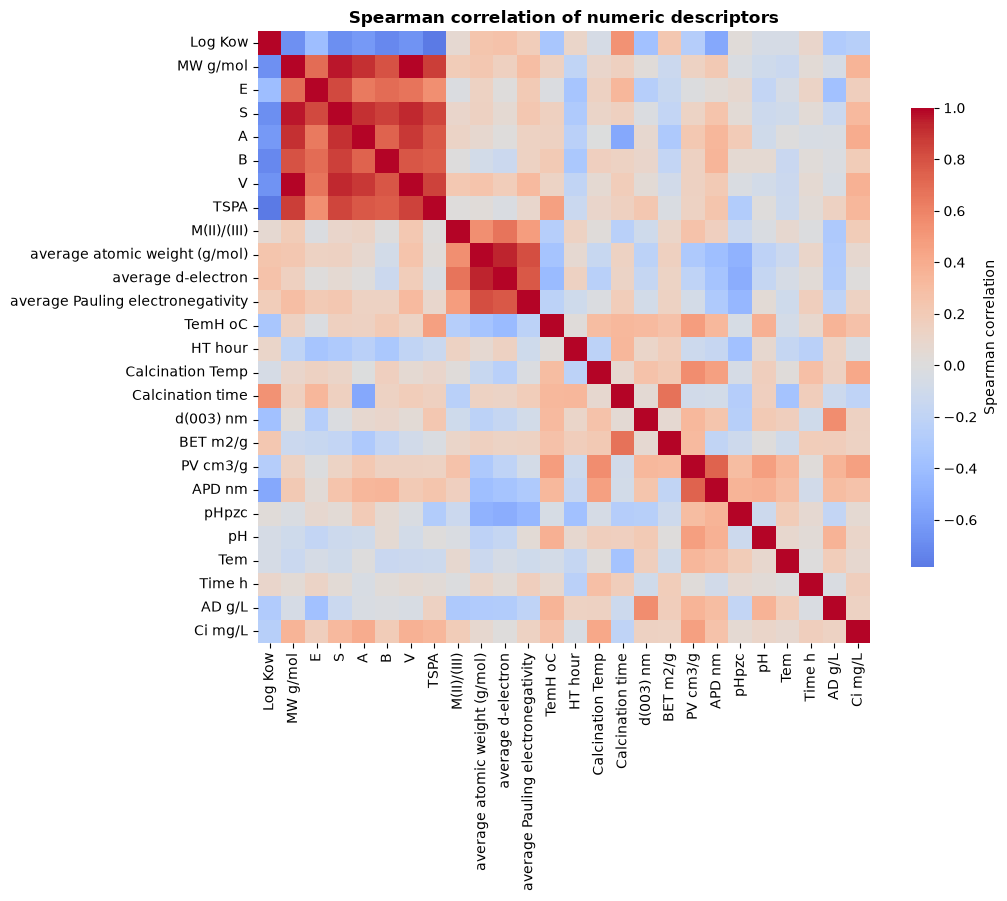

In [10]:
num = X_full.select_dtypes(include=[np.number])
stats = pd.DataFrame({
    'median': num.median(), 'min': num.min(), 'max': num.max(),
    'missing_%': (num.isna().mean() * 100).round(1)}).round(2)
stats.to_csv(FIG_DIR / 'descriptor_stats.csv')
print(stats)

fig, ax = plt.subplots(figsize=(11, 9))
corr = num.corr(method='spearman')
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'shrink': 0.75, 'label': "Spearman correlation"})
ax.set_title('Spearman correlation of numeric descriptors')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_corr_heatmap.png', bbox_inches='tight')
plt.show()

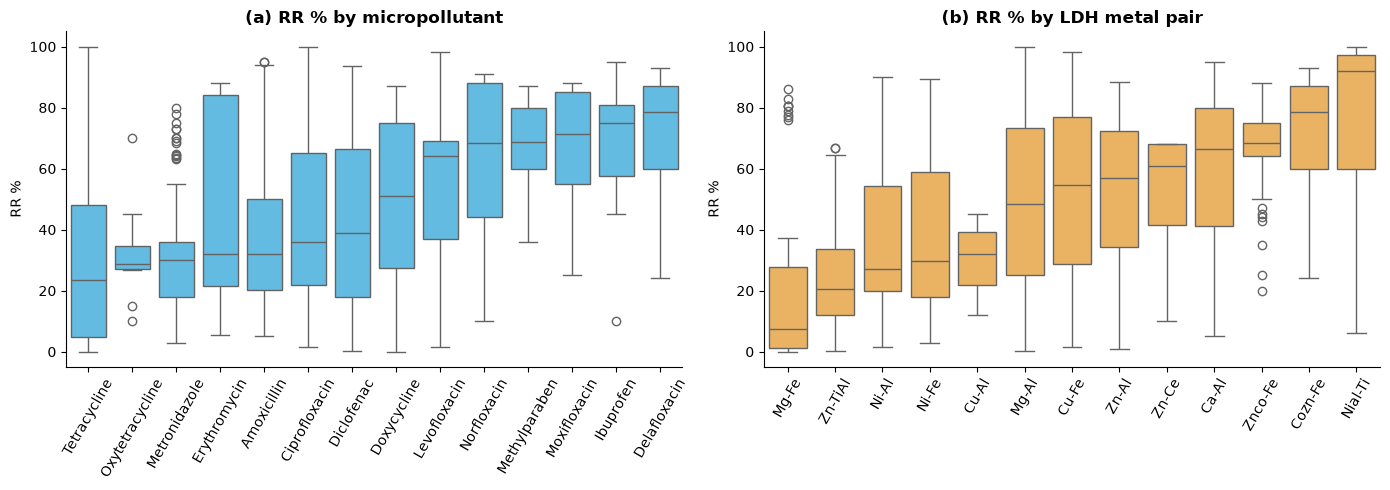

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = df.groupby('TP')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='TP', y='RR %', order=order, ax=axes[0], color='#4FC3F7')
axes[0].set_title('(a) RR % by micropollutant'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=60)
df['metal_pair'] = df['Metal(II)'] + '-' + df['Metal(III)']
mp_order = df.groupby('metal_pair')['RR %'].median().sort_values().index
sns.boxplot(data=df, x='metal_pair', y='RR %', order=mp_order, ax=axes[1], color='#FFB74D')
axes[1].set_title('(b) RR % by LDH metal pair'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_rr.png', bbox_inches='tight')
plt.show()

## A7. Workflow schematic (Fig. 1 / graphical-abstract basis)

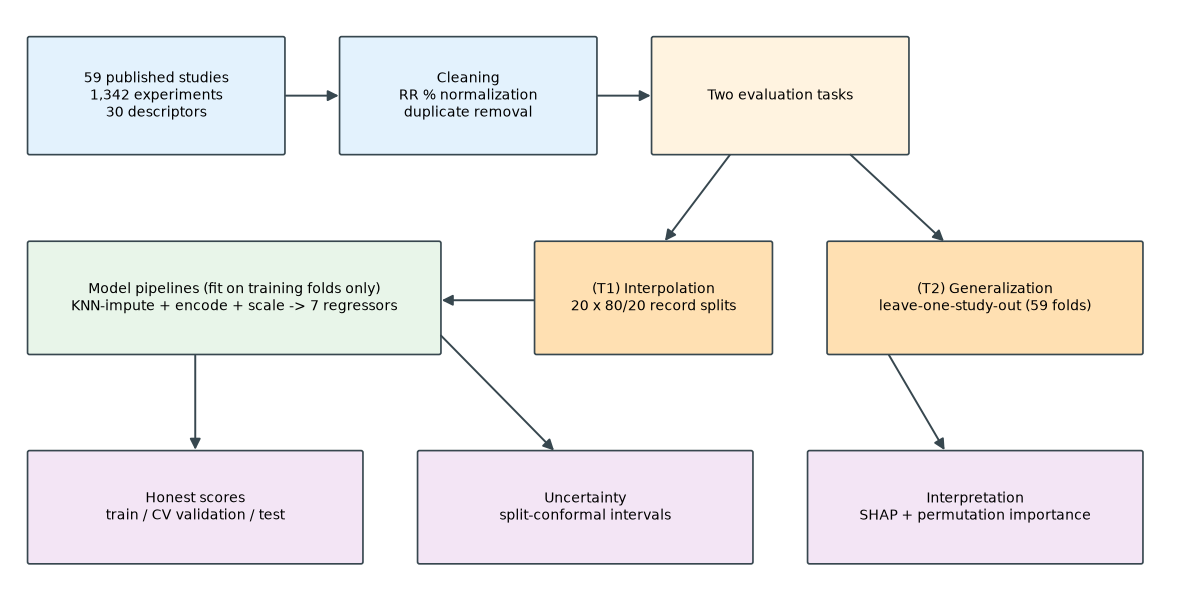

In [12]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def box(ax, xy, w, h, text, fc):
    b = FancyBboxPatch(xy, w, h, boxstyle='round,pad=0.02,rounding_size=0.02',
                       fc=fc, ec='#37474F', lw=1.2)
    ax.add_patch(b)
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha='center', va='center', fontsize=10)

def arrow(ax, p1, p2):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle='-|>', mutation_scale=16,
                                 lw=1.4, color='#37474F'))

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.2); ax.axis('off')

box(ax, (0.2, 4.7), 2.6, 1.2, '59 published studies\n1,342 experiments\n30 descriptors', '#E3F2FD')
box(ax, (3.4, 4.7), 2.6, 1.2, 'Cleaning\nRR % normalization\nduplicate removal', '#E3F2FD')
box(ax, (6.6, 4.7), 2.6, 1.2, 'Two evaluation tasks', '#FFF3E0')
box(ax, (5.4, 2.6), 2.4, 1.15, '(T1) Interpolation\n20 x 80/20 record splits', '#FFE0B2')
box(ax, (8.4, 2.6), 3.2, 1.15, '(T2) Generalization\nleave-one-study-out (59 folds)', '#FFE0B2')
box(ax, (0.2, 2.6), 4.2, 1.15, 'Model pipelines (fit on training folds only)\n'
    'KNN-impute + encode + scale -> 7 regressors', '#E8F5E9')
box(ax, (0.2, 0.4), 3.4, 1.15, 'Honest scores\ntrain / CV validation / test', '#F3E5F5')
box(ax, (4.2, 0.4), 3.4, 1.15, 'Uncertainty\nsplit-conformal intervals', '#F3E5F5')
box(ax, (8.2, 0.4), 3.4, 1.15, 'Interpretation\nSHAP + permutation importance', '#F3E5F5')

arrow(ax, (2.8, 5.3), (3.4, 5.3))
arrow(ax, (6.0, 5.3), (6.6, 5.3))
arrow(ax, (7.4, 4.7), (6.7, 3.75))
arrow(ax, (8.6, 4.7), (9.6, 3.75))
arrow(ax, (5.4, 3.15), (4.4, 3.15))
arrow(ax, (1.9, 2.6), (1.9, 1.55))
arrow(ax, (4.4, 2.8), (5.6, 1.55))
arrow(ax, (9.0, 2.6), (9.6, 1.55))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_workflow.png', bbox_inches='tight', dpi=300)
plt.show()